<h1 style="text-align:center; font-size: 5em;"> Crime Data - Exploratory Data Analysis</h1>
<hr style="border:2px solid">
<h1 style="text-align:center; font-size: 3em;">Report</h1>
<h2 style="text-align:center; font-size: 2em;">Street data Jan 2024 - Dec 2025</h2>
<hr style="border-top:1px dashed">

# Executive summary

Understanding regional crime patterns is an important consideration when evaluating the desirability of locations for residential property markets. Crime levels can influence neighbourhood perception, buyer confidence, property values, and long-term investment potential. This report presents an exploratory analysis of crime data across selected police forces in the United Kingdom, with the objective of providing insights that may support real estate decision-making.

The analysis was conducted for Nadine Green, Head of Sales at a real estate company, who is interested in identifying locations that may be more or less attractive from a property sales and investment perspective. Crime data was obtained from the UK Police open data portal, focusing on street-level crime records over a two-year period. Five police forces were selected for comparison: the Metropolitan Police Service, West Midlands Police, Thames Valley Police, Kent Police, and Devon and Cornwall Police. These forces represent a range of regional environments including major cities, commuter regions, suburban and coastal areas, and rural tourism destinations.

The exploratory analysis investigates several aspects of crime patterns across these regions. First, the distribution of crime across police forces is examined to understand how crime volumes differ between major urban and more rural areas. The analysis then explores the distribution of crime types, highlighting the offences that dominate in the dataset and identifying those that are particularly relevant to residential property markets, such as burglary, vehicle crime, criminal damage, robbery, and anti-social behaviour.

Temporal trends are also analysed to identify seasonal patterns in crime levels. Monthly crime trends reveal fluctuations throughout the year, including noticeable increases during the summer months. Crime composition is further examined through heatmap visualisations that compare crime type distributions across regions, allowing differences in crime structure to be identified.

To enable fair comparison between regions with different population sizes, crime levels are also analysed relative to population using data from the 2021 UK Census. Crime intensity is measured as crimes per 1000 residents, providing a more balanced comparison of regional crime levels. In addition, the analysis explores crime outcomes to understand how frequently cases reach a definitive resolution across different police forces.

The findings reveal clear differences between policing environments. Major metropolitan regions record significantly higher crime volumes, while rural regions generally experience lower overall crime levels. However, when adjusting for population size, crime intensity varies across regions in different ways. The analysis also highlights differences in crime resolution rates, which may reflect variations in investigative complexity and crime volume.

Based on the results of the exploratory analysis, two police forces were selected for further investigation: the Metropolitan Police Service and Devon and Cornwall Police. These forces provide a useful contrast between a major metropolitan property market and a rural tourism-driven region. Future analysis will explore crime patterns within these areas at a more granular geographic level to better understand how local crime dynamics may influence housing market conditions.

# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mtick
import seaborn as sns
import folium
from folium.plugins import HeatMap
import os

# Introduction

Crime patterns can influence perceptions of neighbourhood safety and play an important role in residential property markets. For organisations involved in property sales or investment, understanding how crime levels vary across regions can help identify areas that may present different levels of risk or opportunity.

This report presents an exploratory analysis of crime data across selected UK police forces. The objective is to provide an overview of regional crime patterns and identify locations that may warrant further investigation from a real estate perspective.

## Data Sources

The analysis uses two primary datasets:

Crime data:
Street-level crime records obtained from the UK Police open data portal.

https://data.police.uk/data/

Population data:
Population estimates derived from the 2021 UK Census (TS001 – Number of usual residents), aggregated to match the selected police force areas.

https://www.ons.gov.uk/datasets/TS001/editions/2021/versions/3

## Police Forces Selection

Crime levels influence residential desirability, property demand, and investment potential. This report provides an exploratory analysis of crime across several UK regions to identify patterns relevant to real estate decision-making. The analysis focuses on street crime data from the UK Police open data portal and compares five police forces representing **different geographic contexts**.

The selected forces are:
- Metropolitan Police Service: major global city
- West Midlands Police: major urban city (Birmingham)
- Thames Valley Police: commuter region
- Kent Police: suburban and coastal region
- Devon and Cornwall Police: rural and tourism

## Methodology Overview

The analysis was conducted in Python using Jupyter Notebook and involved two main stages:

**Data preprocessing**

- importing monthly crime datasets
- cleaning missing and duplicated records
- combining multiple police forces
- creating derived variables such as regional environment categories

**Exploratory analysis**

- analysing crime distribution across regions
- examining crime types and trends over time
- visualising spatial patterns
- adjusting crime levels relative to population
- examining crime resolution outcomes

These analyses provide an overview of how crime patterns vary across different policing environments.

# Load the Clean Dataset

In [2]:
# Load the dataset produced in the preprocessing notebook
crime_df = pd.read_csv("crime_all_forces_clean.csv")

crime_df.head()

,crime_id,month,reported_by,falls_within,longitude,latitude,location,lsoa_code,lsoa_name,crime_type,last_outcome_category,year,month_name,region_type
0,0000091b5d32af02f1538cccd3b3f537c199ba083993c6...,2024-03-01,Metropolitan Police Service,Metropolitan Police Service,-0.207530,51.536701,On or near Hopefield Avenue,E01000580,Brent 032B,Violence and sexual offences,Investigation complete; no suspect identified,2024,March,Major city
1,0000140bb444aeeea1ad57148b0e9cb3db55ad41f44b1a...,2025-11-01,Devon & Cornwall Police,Devon & Cornwall Police,-4.002877,50.741384,On or near Supermarket,E01020330,West Devon 002D,Shoplifting,Under investigation,2025,November,Rural / tourism
2,0000184b7a2fe83e5827a71e13479a8aa87f25b3d6709e...,2024-11-01,Metropolitan Police Service,Metropolitan Police Service,-0.226968,51.547437,On or near Richmond Avenue,E01000642,Brent 022D,Theft from the person,Investigation complete; no suspect identified,2024,November,Major city
3,000021988a5755bf56e0bef637315582173a6733ec629e...,2025-05-01,Metropolitan Police Service,Metropolitan Police Service,-0.210288,51.464165,On or near Deodar Road,E01035490,Wandsworth 010H,Violence and sexual offences,Unable to prosecute suspect,2025,May,Major city
4,0000302e21884e2e6efe7c152909343997585387faf8b4...,2024-11-01,Metropolitan Police Service,Metropolitan Police Service,-0.093409,51.496450,On or near Falmouth Road,E01003943,Southwark 009C,Burglary,Investigation complete; no suspect identified,2024,November,Major city


# Dataset Overview

## Check dataset structure

Before analysing the data, we inspect the structure and confirm the police forces included.

In [3]:
crime_df.shape

(3962114, 14)

In [4]:
crime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3962114 entries, 0 to 3962113
Data columns (total 14 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   crime_id               object 
 1   month                  object 
 2   reported_by            object 
 3   falls_within           object 
 4   longitude              float64
 5   latitude               float64
 6   location               object 
 7   lsoa_code              object 
 8   lsoa_name              object 
 9   crime_type             object 
 10  last_outcome_category  object 
 11  year                   int64  
 12  month_name             object 
 13  region_type            object 
dtypes: float64(2), int64(1), object(11)
memory usage: 423.2+ MB


## Check police forces included

In [5]:
crime_df["reported_by"].value_counts()

reported_by
Metropolitan Police Service    2268723
West Midlands Police            664403
Thames Valley Police            384935
Kent Police                     359223
Devon & Cornwall Police         284830
Name: count, dtype: int64

As expected, the dataset contains crime records across five police forces representing different regional contexts in the UK, including metropolitan, urban, commuter, suburban, and rural areas.

# Crime Distribution across Police Forces

Before exploring crime patterns in detail, it is useful to understand how crime volumes differ across the selected regions overall.

This chart compares the total number of crimes recorded by each police force.

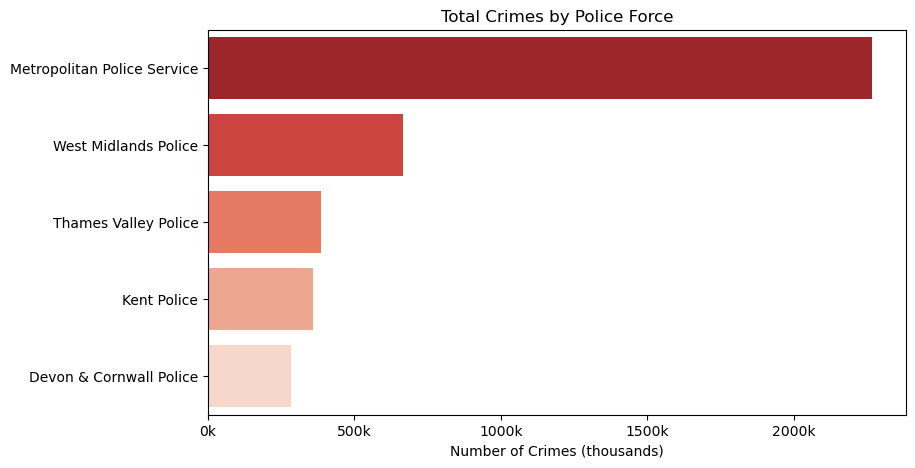

In [6]:
force_counts = crime_df["reported_by"].value_counts().reset_index()
force_counts.columns = ["force","crime_count"]

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=force_counts,
    x="crime_count",
    y="force",
    hue="force",
    palette="Reds_r",
    legend=False
)

# Format x-axis to show values in thousands
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

plt.title("Total Crimes by Police Force")
plt.xlabel("Number of Crimes (thousands)")
plt.ylabel("")

plt.show()

**Insight**: Metropolitan and major urban police forces report the highest crime volumes, which is expected due to higher population density and economic activity.

# Distribution of Crime Types

After understanding where crime occurs, the next question is what types of crimes are most common.

Understanding which types of crime dominate provides insight into the overall safety profile of each region.

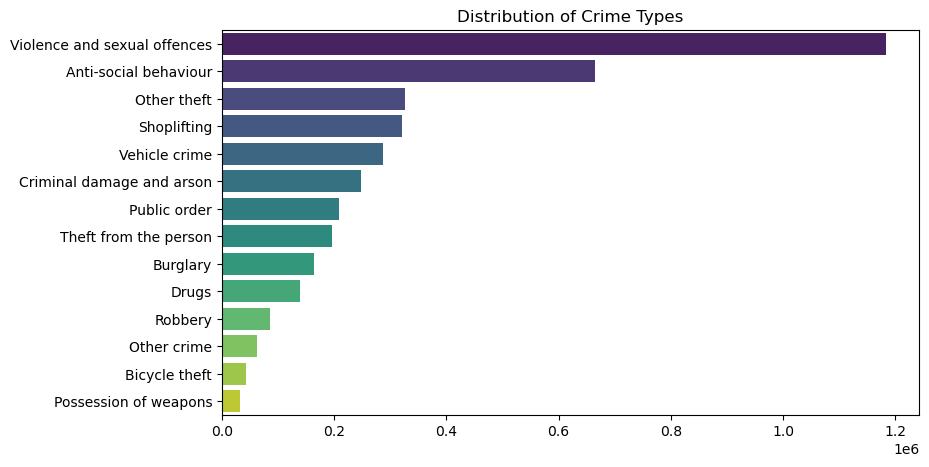

In [7]:
crime_types = crime_df["crime_type"].value_counts().reset_index()
crime_types.columns = ["crime_type","count"]

plt.figure(figsize=(9,5))

sns.barplot(
    data=crime_types,
    x="count",
    y="crime_type",
    hue="crime_type",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Crime Types")
plt.xlabel("")
plt.ylabel("")

plt.show()

**Insight**: Violence and sexual offences represent the largest crime category across the dataset, followed by anti-social behaviour and other theft.

# Crime Types Relevant to Real Estate

Not all crimes affect housing markets equally. To support real estate decision-making, it is useful to focus on crime types that directly impact residential safety and property damage.

## Overview of crime types

Before focusing on crimes relevant to property markets, we first review the eight most common crime categories across the dataset.

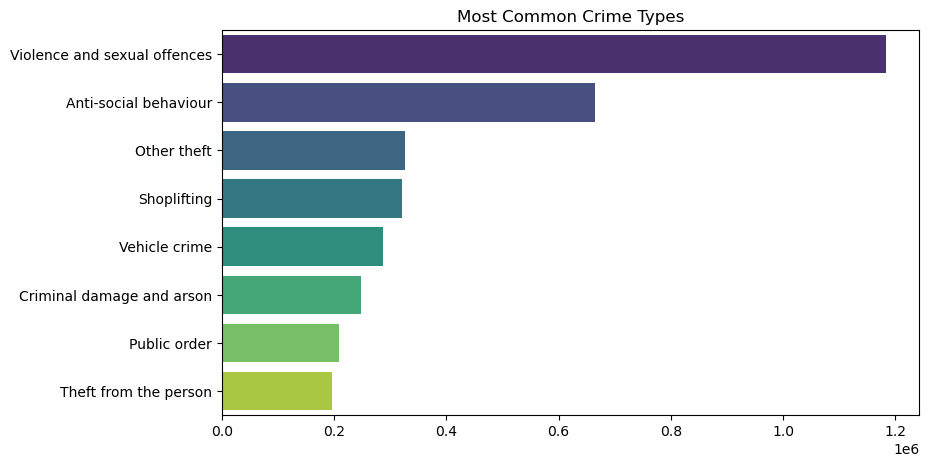

In [8]:
top_crimes = crime_df["crime_type"].value_counts().head(8).reset_index()
top_crimes.columns = ["crime_type","count"]

plt.figure(figsize=(9,5))

sns.barplot(
    data=top_crimes,
    x="count",
    y="crime_type",
    hue="crime_type",
    palette="viridis",
    legend=False
)

plt.title("Most Common Crime Types")
plt.xlabel("")
plt.ylabel("")

plt.show()

## Distribution of Real Estate Relevant Crime Types

While all crimes are important for policing, certain offences are particularly relevant when assessing neighbourhood desirability and property safety.

Crimes most likely to influence housing markets include:
- **burglary**: direct impact on home security
- **vehicle crime**: affects residential parking space
- **criminal damage and arson**: damage to property
- **robbery**: affects personal safety near residential areas
- **anti-social behaviour**: affects neighbourhood perception

These crimes can influence buyer confidence, insurance costs, and property values.

In [9]:
# Filter relevant crimes
realestate_crimes = [
"Burglary",
"Vehicle crime",
"Criminal damage and arson",
"Robbery",
"Anti-social behaviour"
]

realestate_df = crime_df[
    crime_df["crime_type"].isin(realestate_crimes)
]

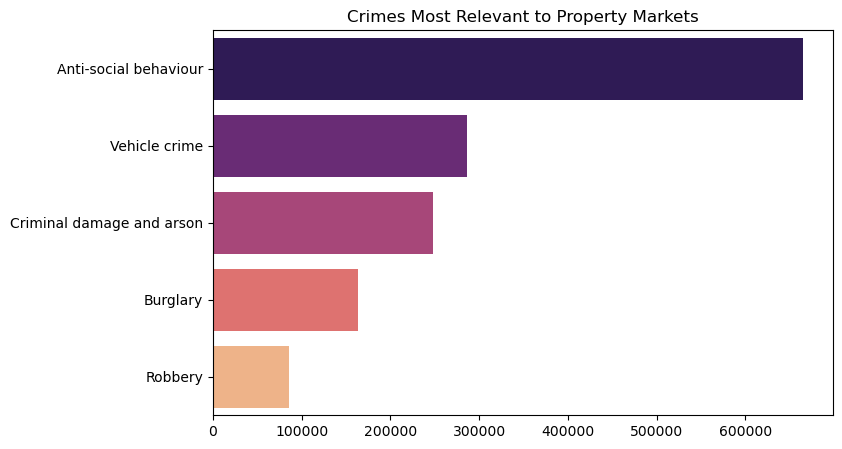

In [10]:
re_counts = realestate_df["crime_type"].value_counts().reset_index()
re_counts.columns = ["crime_type","count"]

plt.figure(figsize=(8,5))

sns.barplot(
    data=re_counts,
    x="count",
    y="crime_type",
    hue="crime_type",
    palette="magma",
    legend=False
)

plt.title("Crimes Most Relevant to Property Markets")
plt.xlabel("")
plt.ylabel("")

plt.show()

**Insight**: Among crimes relevant to property markets, anti-social behaviour and vehicle crime occur most frequently, suggesting these issues may have the greatest influence on neighbourhood desirability.

## Comparison of Property-Related Crimes

To understand how property-related crime varies across regions, we compare these categories across the selected police forces.

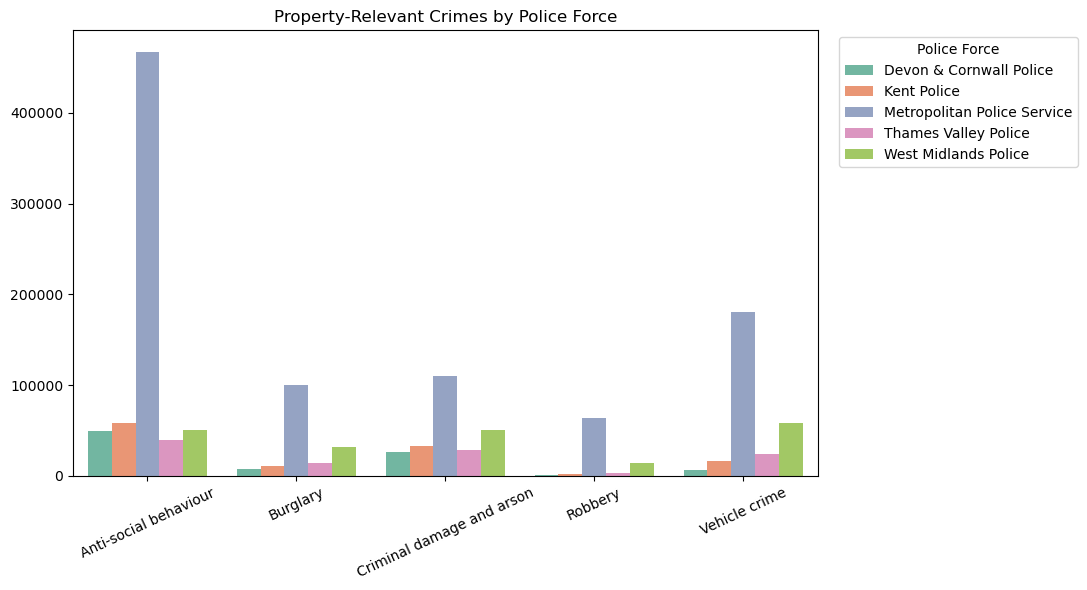

In [11]:
# Aggregate crime counts
crime_focus = realestate_df.groupby(
    ["reported_by","crime_type"]
).size().reset_index(name="count")

plt.figure(figsize=(11,6))

sns.barplot(
    data=crime_focus,
    x="crime_type",
    y="count",
    hue="reported_by",
    palette="Set2"
)

plt.title("Property-Relevant Crimes by Police Force")
plt.xlabel("")
plt.ylabel("")

plt.xticks(rotation=25)

plt.legend(
    title="Police Force",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

**Insight**: The Metropolitan Police Service reports substantially higher counts across all property-related crime categories, which is expected given the scale, population density, and economic activity of London. In particular, anti-social behaviour incidents are vastly higher in the Metropolitan area compared with other police forces

## Comparison of Real Estate Relevant crime types excluding Metropolitan Police Service

Because the Metropolitan Police Service records substantially higher crime counts than the other forces, we create a second comparison excluding it. This allows clearer comparison between the remaining regions.

In [12]:
# Create dataset excluding Metropolitan Police Service
non_metro_df = realestate_df[
    realestate_df["reported_by"] != "Metropolitan Police Service"
]

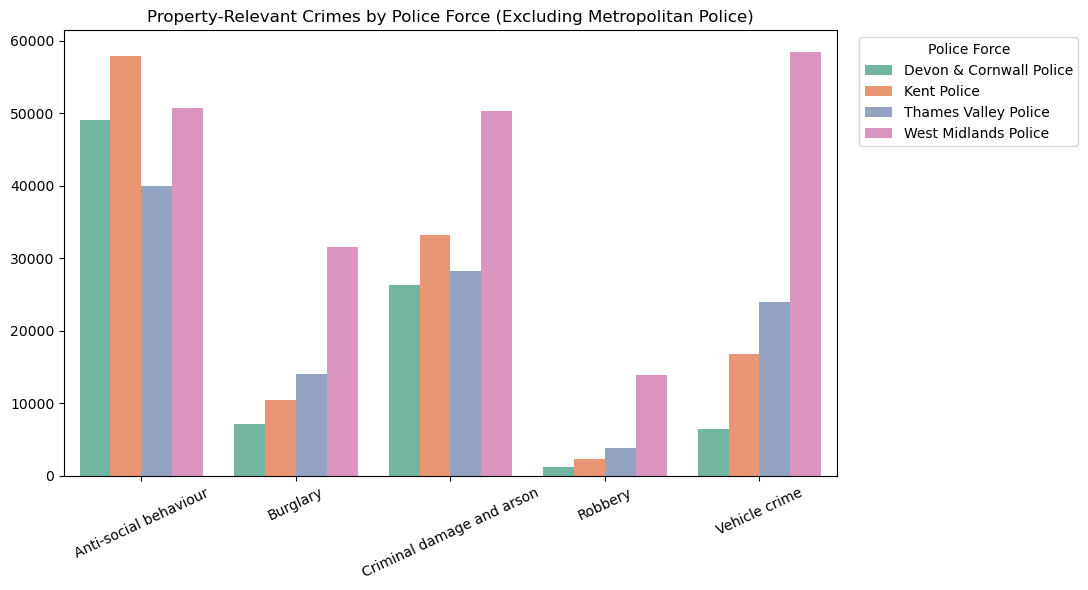

In [13]:
# Aggregate crime counts
crime_focus_non_metro = non_metro_df.groupby(
    ["reported_by", "crime_type"]
).size().reset_index(name="count")

plt.figure(figsize=(11,6))

sns.barplot(
    data=crime_focus_non_metro,
    x="crime_type",
    y="count",
    hue="reported_by",
    palette="Set2"
)

plt.title("Property-Relevant Crimes by Police Force (Excluding Metropolitan Police)")
plt.xlabel("")
plt.ylabel("")

plt.xticks(rotation=25)

plt.legend(
    title="Police Force",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

**Insight**: When the Metropolitan Police Service is excluded, clearer differences between the remaining regions become visible. 

Anti-social behaviour is most prevalent in Kent, followed by West Midlands Police, with Devon and Cornwall and Thames Valley reporting similar but slightly lower levels. 

For several other property-related crimes, West Midlands Police consistently records the highest counts, including burglary, criminal damage and arson, robbery, and vehicle crime. 

Thames Valley Police typically ranks second, particularly for burglary, robbery, and vehicle crime, reflecting its commuter-region characteristics. 

Kent Police generally shows moderate levels across these crime types, while Devon and Cornwall Police records the lowest counts overall, particularly for vehicle crime. 

These patterns highlight the contrast between urban environments such as the West Midlands and more rural areas like Devon and Cornwall, where crime levels are generally lower and more stable.

# Crime Trends over Time

After understanding crime distribution and types, the next step is to examine how crime levels evolve over time.

Examining crime over time helps identify seasonal trends.

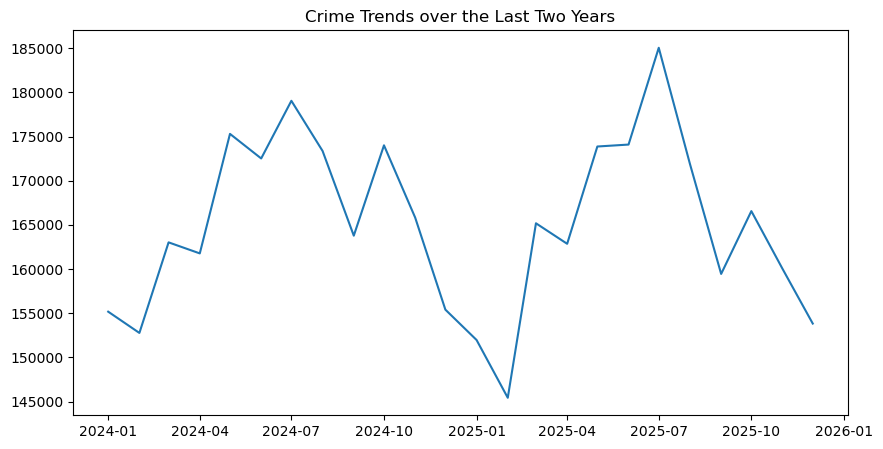

In [14]:
crime_df["month"] = pd.to_datetime(crime_df["month"])

monthly_crime = crime_df.groupby("month").size()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_crime.index,
    y=monthly_crime.values
)

plt.title("Crime Trends over the Last Two Years")
plt.xlabel("")
plt.ylabel("")

plt.show()

**Insight**: Crime levels fluctuate moderately over time, suggesting seasonal variation rather than a long-term upward or downward trend. Crime levels show a clear seasonal pattern, with higher numbers of recorded incidents during the summer months. This increase may be associated with greater outdoor activity, tourism, and social interaction during warmer periods, which can lead to more opportunities for certain types of crime such as 'Anti-social behaviour'.

# Crime Trends by Police Force

Overall crime trends may differ across regions. This section compares how crime patterns change over time across police forces.

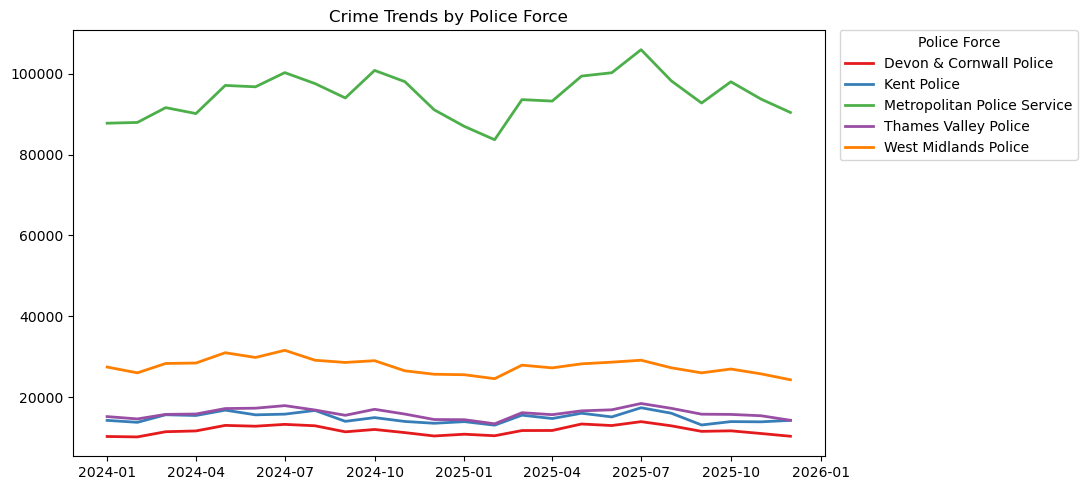

In [15]:
crime_time_force = crime_df.groupby(
    ["month","reported_by"]
).size().reset_index(name="crime_count")

plt.figure(figsize=(11,5))

ax = sns.lineplot(
    data=crime_time_force,
    x="month",
    y="crime_count",
    hue="reported_by",
    palette="Set1",   # strong contrasting colours
    linewidth=2
)

plt.title("Crime Trends by Police Force")
plt.xlabel("")
plt.ylabel("")

# Move legend outside
plt.legend(
    title="Police Force",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()

plt.show()

**Insight**: Crime levels vary across police forces, with metropolitan and urban regions generally recording higher crime counts than suburban and rural areas. The Metropolitan Police Service also shows greater fluctuations in crime levels over time, whereas the other police forces display relatively stable patterns throughout the period. This suggests that crime dynamics may be more volatile in large metropolitan environments compared with smaller or more rural regions.

# Crime Composition by Police Force

After examining overall crime trends, it is useful to understand how the composition of crime differs between regions.

Different police forces may experience different types of crime depending on factors such as urbanisation, population density, and local economic activity.

To examine these differences, the following heatmap compares the distribution of crime types across the selected police forces.

## Crime Type Distribution across All Police Forces

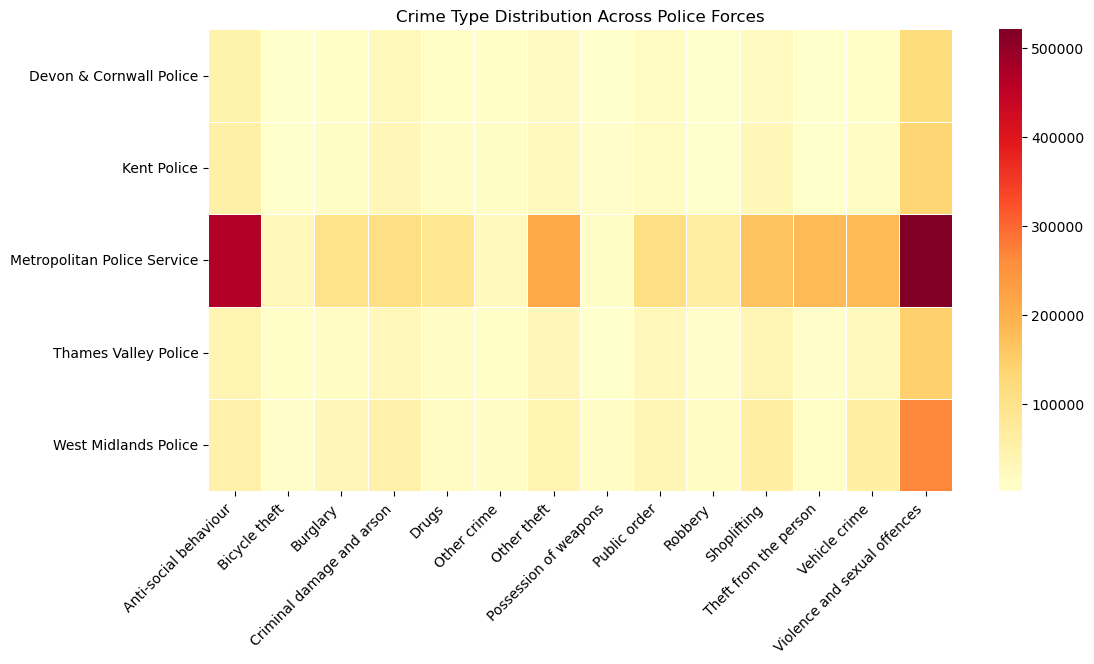

In [16]:
crime_matrix = crime_df.groupby(
    ["reported_by","crime_type"]
).size().reset_index(name="count")

crime_pivot = crime_matrix.pivot(
    index="reported_by",
    columns="crime_type",
    values="count"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    crime_pivot,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Crime Type Distribution Across Police Forces")
plt.xlabel("")
plt.ylabel("")

plt.xticks(rotation=45, ha="right")

plt.show()

**Insight**: The matrix heatmap illustrates how crime types are distributed across the selected police forces. The Metropolitan Police Service records the highest counts across nearly all crime categories, reflecting the scale, population density, and economic activity of London. 

Among the crime types, violence and sexual offences appear as the most prominent category, shown by the deepest red shading across multiple police forces. This indicates that it is consistently the most frequent crime type in the dataset. 

Other crimes such as anti-social behaviour, theft-related offences, and vehicle crime are also visible across regions, though typically at lower levels. However, because the Metropolitan Police Service records substantially higher crime counts overall, the colour scale becomes dominated by these values, making differences between the remaining police forces less visible in this initial comparison.

## Crime Composition Excluding the Metropolitan Police Service

The previous matrix heatmap demonstrated that the Metropolitan Police Service records substantially higher crime counts than the other police forces, which reduces the visibility of differences between the remaining regions. Additionally, the crime category “Violence and sexual offences” dominates the dataset, appearing as the most frequent crime type across all police forces.

To better highlight regional differences across other crime categories, the following matrix heatmap excludes both the Metropolitan Police Service and violence and sexual offences. This allows smaller variations between the remaining police forces and crime types to become more visible.

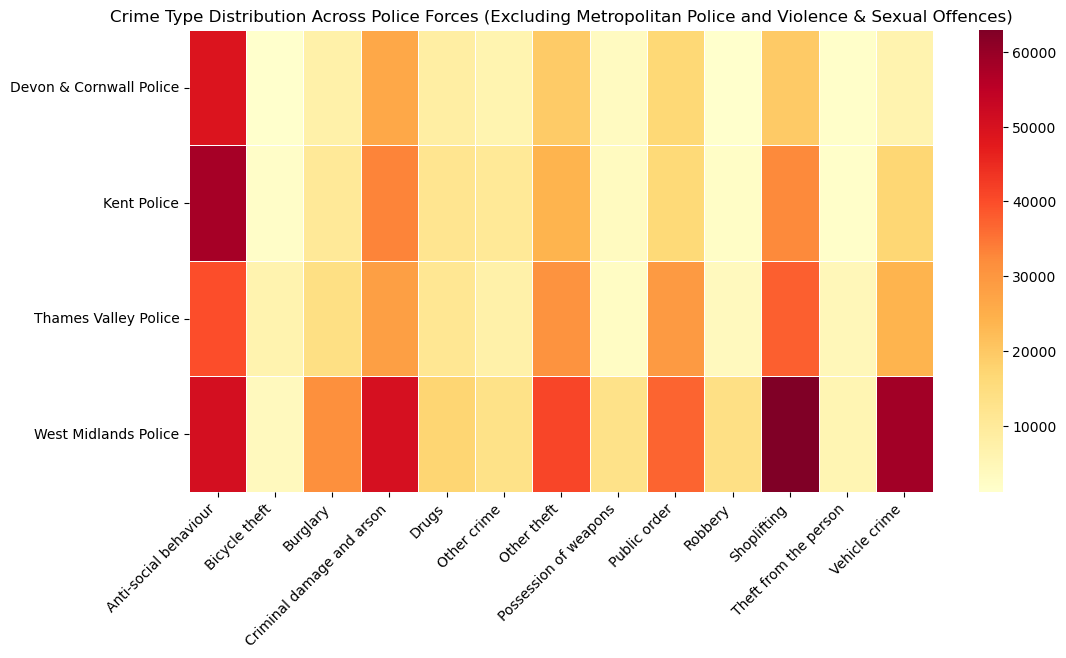

In [17]:
crime_df_filtered = crime_df[
    (crime_df["reported_by"] != "Metropolitan Police Service") &
    (crime_df["crime_type"] != "Violence and sexual offences")
]

crime_matrix_filtered = crime_df_filtered.groupby(
    ["reported_by","crime_type"]
).size().reset_index(name="count")

crime_pivot_filtered = crime_matrix_filtered.pivot(
    index="reported_by",
    columns="crime_type",
    values="count"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    crime_pivot_filtered,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Crime Type Distribution Across Police Forces (Excluding Metropolitan Police and Violence & Sexual Offences)")
plt.xlabel("")
plt.ylabel("")

plt.xticks(rotation=45, ha="right")

plt.show()

**Insight**: The heatmap highlights differences in crime composition across the remaining police forces once the Metropolitan Police Service and the dominant category of violence and sexual offences are excluded. 

West Midlands Police records the highest counts across several crime categories, particularly shoplifting, vehicle crime, criminal damage and arson, and other theft, reflecting the characteristics of a dense urban environment with significant retail and commercial activity. 

Thames Valley Police shows moderate levels across most crime types, with relatively higher counts in shoplifting, other theft, and public order offences, which may reflect its mix of commuter towns and urban centres. 

Kent Police generally displays moderate crime levels, with anti-social behaviour appearing as the most prominent category. 

In contrast, Devon and Cornwall Police consistently records the lowest counts across nearly all crime categories, particularly robbery, bicycle theft, and possession of weapons, reflecting the more rural nature of the region. 

Overall, the comparison illustrates how urban regions tend to experience higher levels of property and retail-related crime, while rural regions show lower and more concentrated crime patterns.

# Regional Crime Comparison Map

Having explored crime patterns statistically, it is helpful to visualise how crime is distributed geographically across the UK (for the selected police forces).

The following map compares overall crime levels across the selected police forces.

Each marker represents a police force region, with marker size proportional to the total number of crimes recorded.

This allows a quick spatial comparison of crime intensity across regions. Clicking on each marker provides the crime count for the relevant police force.

In [18]:
# Calculate crime counts
force_counts = crime_df.groupby("reported_by").size().reset_index(name="crime_count")

# Convert to thousands for readability
force_counts["crime_count_k"] = force_counts["crime_count"] / 1000

# Define the centre of each policing region.
force_locations = {
    "Metropolitan Police Service": [51.5074,-0.1278],
    "West Midlands Police": [52.4862,-1.8904],
    "Thames Valley Police": [51.7520,-1.2577],
    "Kent Police": [51.2787,0.5217],
    "Devon & Cornwall Police": [50.7184,-3.5339]
}

force_map = folium.Map(
    location=[53,-2],
    zoom_start=6,
    tiles="cartodbpositron"
)

for _, row in force_counts.iterrows():

    location = force_locations[row["reported_by"]]

    folium.CircleMarker(
        location=location,
        radius=row["crime_count"]/50000,
        popup=f"{row['reported_by']}<br>{int(row['crime_count_k'])}k crimes",
        color="darkred",
        fill=True,
        fill_opacity=0.7
    ).add_to(force_map)

force_map

**Insight**: The map highlights strong regional differences in crime levels across the selected police forces. Metropolitan areas, particularly London, show substantially higher crime volumes, while rural regions such as Devon and Cornwall report significantly fewer incidents. These spatial differences reflect variations in population density, urbanisation, and economic activity across regions.

# Crime Intensity Relative to Population

Crime totals are influenced by population size. Larger cities naturally record more crimes simply because more people live there.

To allow fair comparison between regions, crime counts are normalised by population to calculate the number of crimes per 1,000 residents.

Population figures were obtained from the 2021 UK Census (TS001: Number of usual residents) and aggregated to the corresponding police force areas.

In [19]:
# Load population dataset
population_df = pd.read_csv("population_by_police_force.csv")
population_df

,reported_by,population
0,Devon & Cornwall Police,976377
1,Kent Police,1855844
2,Metropolitan Police Service,8799728
3,Thames Valley Police,2353759
4,West Midlands Police,2919653


In [20]:
# Create crime counts per police force
crime_counts = crime_df.groupby("reported_by").size().reset_index(name="crime_count")

crime_counts

,reported_by,crime_count
0,Devon & Cornwall Police,284830
1,Kent Police,359223
2,Metropolitan Police Service,2268723
3,Thames Valley Police,384935
4,West Midlands Police,664403


In [21]:
# Merge both datasets
crime_population = pd.merge(
    crime_counts,
    population_df,
    on="reported_by"
)

crime_population

,reported_by,crime_count,population
0,Devon & Cornwall Police,284830,976377
1,Kent Police,359223,1855844
2,Metropolitan Police Service,2268723,8799728
3,Thames Valley Police,384935,2353759
4,West Midlands Police,664403,2919653


In [22]:
# Calculate crime rate per 1000 residents
crime_population["crime_rate_per_1000"] = (
    crime_population["crime_count"] /
    crime_population["population"]
) * 1000
crime_population

,reported_by,crime_count,population,crime_rate_per_1000
0,Devon & Cornwall Police,284830,976377,291.721333
1,Kent Police,359223,1855844,193.563144
2,Metropolitan Police Service,2268723,8799728,257.817401
3,Thames Valley Police,384935,2353759,163.540532
4,West Midlands Police,664403,2919653,227.562316


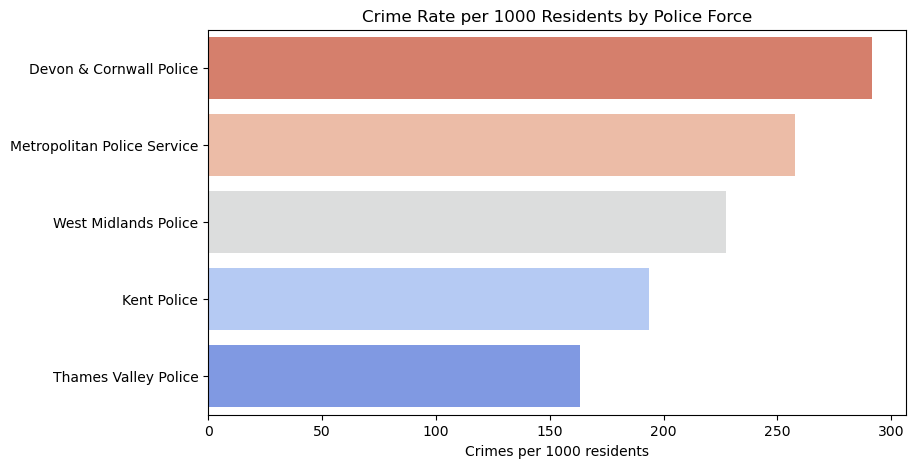

In [23]:
# Visualisation
crime_population_sorted = crime_population.sort_values(
    "crime_rate_per_1000",
    ascending=False
)

plt.figure(figsize=(9,5))

sns.barplot(
    data=crime_population_sorted,
    x="crime_rate_per_1000",
    y="reported_by",
    hue="reported_by",
    palette="coolwarm_r",
    legend=False
)

plt.title("Crime Rate per 1000 Residents by Police Force")
plt.xlabel("Crimes per 1000 residents")
plt.ylabel("")

plt.show()

When crime levels are adjusted for population size, the relative intensity of crime across regions becomes clearer. Devon and Cornwall Police shows the highest crime rate per 1000 residents, despite having one of the lowest total crime counts. This suggests that although the absolute number of incidents is lower, crime represents a larger share relative to the size of the local population.

The Metropolitan Police Service and West Midlands Police follow, reflecting the influence of dense urban environments where higher levels of social interaction, economic activity, and tourism may contribute to increased crime rates.

Kent Police and Thames Valley Police display comparatively lower crime rates, indicating relatively safer environments when considering population size. These regions include a mix of suburban and commuter areas, which may contribute to more stable crime patterns compared with large metropolitan centres.

# Crime Outcomes and Resolution Patterns

Beyond the frequency of crimes, it is also important to understand how crimes are resolved, as this may influence perceptions of safety and policing effectiveness.

The dataset includes the variable last outcome category, which describes the most recent status of each investigation.

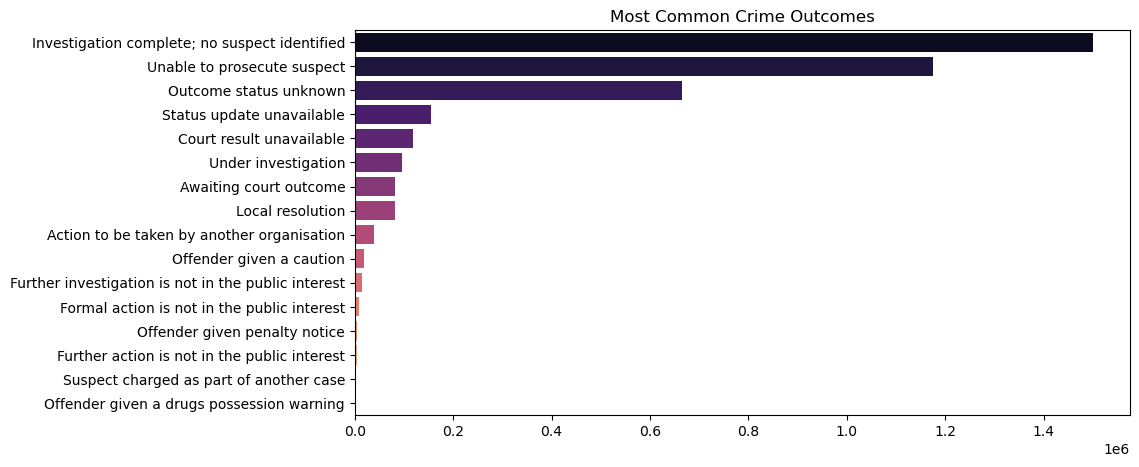

In [24]:
outcome_counts = crime_df["last_outcome_category"].value_counts().reset_index()
outcome_counts.columns = ["outcome","count"]

plt.figure(figsize=(10,5))

sns.barplot(
    data=outcome_counts,
    x="count",
    y="outcome",
    hue="outcome",
    palette="magma",
    legend=False
)

plt.title("Most Common Crime Outcomes")
plt.xlabel("")
plt.ylabel("")

plt.show()

**Insight**: The majority of crimes fall into categories such as “Investigation complete; no suspect identified” or “Unable to prosecute suspect”, indicating that many cases do not lead to formal charges. This reflects the large crime datasets considered, as they include offences where identifying a suspect may be difficult.

A smaller proportion of cases result in outcomes such as “Suspect charged as part of another case”, “Local resolution”, or “Offender given a caution”, which represent successful resolutions or alternative policing actions.

Understanding these outcomes provides additional context when interpreting crime data, as it highlights the challenges associated with investigating and resolving certain offences.

# Crime Resolution Rates by Police Force

Crime outcomes provide insight into policing responses and the extent to which investigations lead to a final resolution.

For this analysis, a crime is considered resolved when the recorded outcome indicates that the case has reached a definitive conclusion. This includes situations where enforcement action was taken, where the offender was identified, or where a formal decision was made regarding the investigation.

The following outcome categories are therefore treated as resolved cases:
- Local resolution
- Offender given a caution
- Offender given penalty notice
- Action to be taken by another organisation
- Further investigation is not in the public interest
- Formal action is not in the public interest
- Further action is not in the public interest
- Suspect charged as part of another case
- Offender given a drugs possession warning

The following visualisation compares resolution rates across the selected police forces.

In [25]:
# Define resolution categories

resolution_categories = [
"Local resolution",
"Offender given a caution",
"Offender given penalty notice",
"Action to be taken by another organisation",
"Further investigation is not in the public interest",
"Formal action is not in the public interest",
"Further action is not in the public interest",
"Suspect charged as part of another case",
"Offender given a drugs possession warning"
]

# Create Boolean column for resolved cases
crime_df["resolved"] = crime_df["last_outcome_category"].isin(resolution_categories)

resolution_rate = crime_df.groupby("reported_by")["resolved"].mean().reset_index()

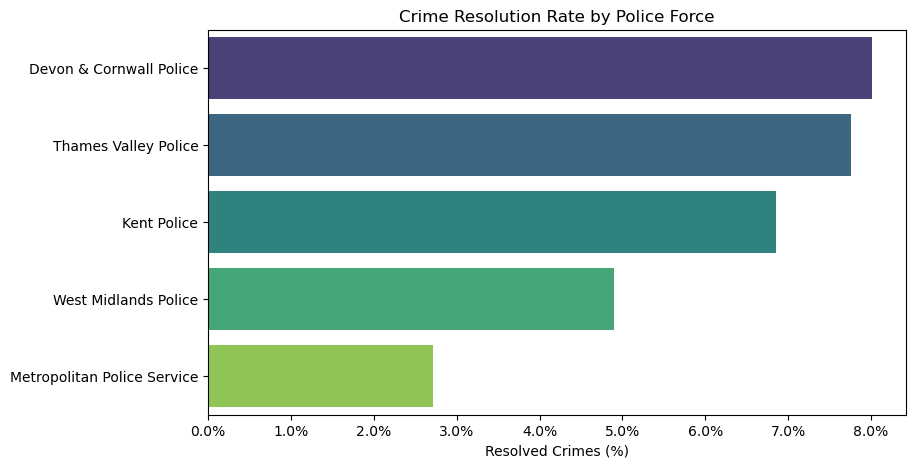

In [26]:
# Sort resolution rates
resolution_rate_sorted = resolution_rate.sort_values(
    "resolved",
    ascending=False
)

plt.figure(figsize=(9,5))

sns.barplot(
    data=resolution_rate_sorted,
    x="resolved",
    y="reported_by",
    order=resolution_rate_sorted["reported_by"],
    hue="reported_by",
    palette="viridis",
    legend=False
)

plt.title("Crime Resolution Rate by Police Force")
plt.xlabel("Resolved Crimes (%)")
plt.ylabel("")

# convert proportion → percentage on axis
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.show()

**Insight**: The resolution rate comparison reveals noticeable differences between police forces. 

Devon and Cornwall Police records the highest proportion of resolved crimes at approximately 8%, suggesting that a larger share of reported incidents reach a definitive outcome compared with other regions. 

Thames Valley Police and Kent Police follow with resolution rates of around 7%, indicating relatively similar performance in terms of case outcomes. 

In contrast, West Midlands Police shows a lower resolution rate of roughly 5%, while the Metropolitan Police Service records the lowest proportion, at under 3%. 

This pattern may partly reflect the challenges faced by policing in large metropolitan environments, where higher crime volumes and greater complexity can make investigations more difficult. Smaller or more rural forces, such as Devon and Cornwall, may benefit from lower crime volumes and more localised contexts, which could contribute to a higher proportion of cases reaching resolution.

# Crime Patterns by Force Environment

The previous sections examined crime patterns across individual police forces, highlighting differences in crime volume, crime composition, and resolution rates. However, many of these differences may be influenced by broader regional characteristics such as urbanisation, population density, and economic activity.

To explore this further, police forces were grouped into broader regional environment categories during the preprocessing stage. This categorisation allows the analysis to examine whether crime patterns follow broader structural differences between metropolitan, commuter, suburban, and rural regions.

The police forces were classified as follows:
- Metropolitan Police Service: major city
- West Midlands Police: major city
- Thames Valley Police: commuter region
- Kent Police: suburban / coastal
- Devon & Cornwall Police: rural / tourism

The dataset already includes this classification in the variable region_type, which was created during preprocessing.

By grouping police forces according to these regional characteristics, we can examine how crime levels vary across different types of environments, rather than focusing only on individual police forces.

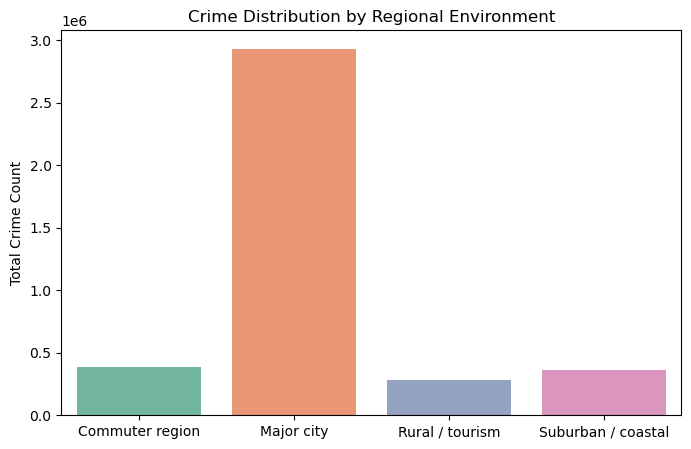

In [27]:
crime_region = crime_df.groupby(
    "region_type"
).size().reset_index(name="crime_count")

plt.figure(figsize=(8,5))

sns.barplot(
    data=crime_region,
    x="region_type",
    y="crime_count",
    hue="region_type",
    palette="Set2",
    legend=False
)

plt.title("Crime Distribution by Regional Environment")
plt.xlabel("")
plt.ylabel("Total Crime Count")

plt.show()

**Insight**: The visualisation highlights clear differences in crime levels across regional environments. Major city police forces record substantially higher crime volumes, reflecting the influence of high population density, economic activity, and greater levels of social interaction typically found in large metropolitan areas. Notably, this category includes two police forces (Metropolitan Police Service and West Midlands Police), which partly contributes to its higher overall crime count. However, even when considering this, the pattern still aligns with previous findings throughout the analysis that urban environments experience higher crime levels than less densely populated regions.

In comparison, commuter and suburban regions display more moderate crime levels, reflecting their mixed urban–residential character and proximity to larger cities. 

Finally, rural regions record significantly lower crime volumes, with fewer incidents across most crime categories. These patterns reinforce the broader conclusion that crime levels tend to increase with urbanisation and population density, while rural areas generally experience lower crime levels and more stable crime patterns.

# Key Insights

The exploratory analysis reveals several important patterns in crime across the selected police forces.

**Crime levels vary significantly between regions.**
Major metropolitan police forces record substantially higher crime volumes than suburban and rural regions. This reflects the influence of population density, economic activity, and increased social interaction in urban environments.

**Violence and sexual offences represent the most common crime type.**
Across all regions, this category appears as the most frequent crime recorded in the dataset, indicating that interpersonal offences dominate the crime landscape.

**Property-related crimes vary across regions.**
Offences such as vehicle crime, burglary, and criminal damage are more prominent in urban environments, while rural areas generally record lower levels of these crimes.

**Crime levels exhibit seasonal variation.**
Monthly trends show noticeable increases in crime during the summer months, likely reflecting increased outdoor activity, tourism, and social interaction.

**Population-adjusted crime rates provide a more balanced comparison.**
When crime counts are adjusted relative to population size, regional differences become clearer. This highlights how large cities naturally generate higher crime volumes due to their larger populations.

**Crime resolution rates differ between police forces.**
Smaller or less densely populated regions tend to show slightly higher proportions of resolved cases, whereas metropolitan regions may face greater investigative challenges due to higher crime volumes and case complexity.

**Regional environment strongly influences crime patterns.**
Grouping police forces into broader regional environments shows that crime intensity tends to increase with urbanisation, while rural regions typically experience lower crime levels.

# Conclusions

Overall, the analysis demonstrates that crime patterns across the selected police forces are strongly influenced by regional characteristics such as population density, urbanisation, and economic activity.

Major metropolitan areas experience higher crime volumes and more diverse crime patterns, while rural regions tend to record fewer crimes and more stable trends over time. Commuter and suburban regions generally fall between these two extremes.

For stakeholders in the real estate sector, these findings highlight the importance of considering crime patterns when evaluating regional desirability and property investment opportunities. Crime levels can influence neighbourhood perception, buyer confidence, and long-term housing demand.

# Selection of Police Forces for Future Study

The purpose of the exploratory analysis was to gain an overview of crime patterns across different regions of the United Kingdom and identify areas that may warrant further investigation. By examining crime distribution, crime composition, temporal trends, population-adjusted crime rates, and resolution outcomes, the analysis highlights clear differences between police forces operating in different regional environments.

Based on these findings, two police forces were selected for deeper analysis in the next stage of the project. The selected forces are the Metropolitan Police Service and Devon and Cornwall Police as they represent contrasting regional environments, allowing a more detailed investigation of how crime dynamics differ between major metropolitan areas and rural regions.

## Metropolitan Police Service

The Metropolitan Police Service was selected because it represents the largest and most complex policing environment among the forces included in the analysis. The region records the highest overall crime volume and shows significant variation across different crime categories, reflecting the characteristics of a large metropolitan area with high population density and economic activity.

However, the Metropolitan Police Service covers the entire Greater London area, which includes neighbourhoods with widely varying demographic, social, and economic characteristics. London is one of the most economically dynamic and internationally attractive cities in the United Kingdom, and this diversity may lead to considerable variation in crime patterns across boroughs.

A future stage of the analysis could therefore investigate whether crime rates differ significantly between areas within London, and how these differences relate to factors such as population density, commercial activity, housing markets, and local socio-economic conditions. Exploring these internal variations could provide valuable insights into how crime patterns affect different types of urban neighbourhoods.

## Devon and Cornwall Police

The Devon and Cornwall Police region was selected as a contrasting case study representing a predominantly rural and tourism-oriented environment. Compared with metropolitan regions, this area records significantly lower overall crime volumes and more stable crime patterns across most categories.

However, when crime levels were adjusted for population size, Devon and Cornwall displayed the highest crime rate per 1000 residents among the analysed forces. While the total number of incidents remains relatively low, this result suggests that crime represents a larger share relative to the resident population.

One possible explanation for this finding is the strong tourism activity within the region. Devon and Cornwall include several well-known coastal destinations that attract large numbers of visitors, particularly during peak holiday seasons. These temporary increases in population may influence local crime dynamics, especially in areas with high tourism activity.

Future analysis could therefore examine whether crime patterns differ between tourism-heavy areas and more residential or rural parts of the region. For real estate decision-making, this distinction could be particularly relevant, as properties located in tourism-driven locations may experience different risk dynamics compared with those in more stable residential communities.